In [ ]:
from google.colab import files

uploaded = files.upload()

Saving mushrooms.csv to mushrooms.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    SimpleRNN,
    Dropout
)

df = pd.read_csv("mushrooms.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Column Counts:")
print(df.iloc[:, 0].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  sta

In [ ]:
# Separate features and target
X = df.drop("class", axis=1)
y = df["class"]

# Convert categorical features into numbers
X = pd.get_dummies(X, dtype=int)

# Convert target classes into numbers
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target classes:", encoder.classes_)
print("Preprocessing completed!")

Features shape: (8124, 117)
Target shape: (8124,)
Target classes: ['e' 'p']
Preprocessing completed!


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5686
Testing samples: 2438


In [ ]:
# Convert data into NumPy arrays
X_train_array = X_train.to_numpy(dtype="float32")
X_test_array = X_test.to_numpy(dtype="float32")

# Reshape for CNN and RNN
X_train_dl = X_train_array.reshape(
    X_train_array.shape[0], X_train_array.shape[1], 1
)

X_test_dl = X_test_array.reshape(
    X_test_array.shape[0], X_test_array.shape[1], 1
)

print("Training data shape:", X_train_dl.shape)
print("Testing data shape:", X_test_dl.shape)
print("Reshaping completed!")

Training data shape: (5686, 117, 1)
Testing data shape: (2438, 117, 1)
Reshaping completed!


In [ ]:
# Build CNN model
cnn_model = Sequential([
    Conv1D(32, kernel_size=3, activation="relu",
           input_shape=(X_train_dl.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

# Compile CNN model
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
cnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 115, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 57, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1824)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       116,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,993 (457.00 KB)

 Trainable params: 116,993 (457.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train CNN model
cnn_history = cnn_model.fit(
    X_train_dl,
    y_train,
    batch_size=30,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9468 - loss: 0.1549 - val_accuracy: 0.9798 - val_loss: 0.0574
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9934 - loss: 0.0272 - val_accuracy: 0.9982 - val_loss: 0.0127
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9978 - loss: 0.0104 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9996 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9991 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 9.6747e-04
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 8.5710e-04
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 7.7331e-04 - val_accuracy: 1.0000 - val_loss: 3.7313e-04
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 6.7150

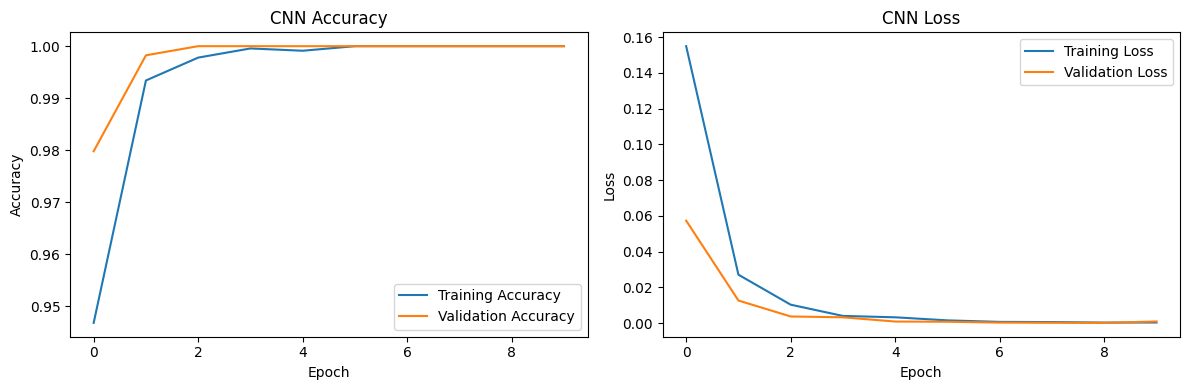

In [ ]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Training Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Generate CNN predictions
cnn_predictions = cnn_model.predict(X_test_dl)

# Convert probabilities into class labels
cnn_predictions = (cnn_predictions > 0.5).astype(int).flatten()

# Calculate test accuracy
cnn_accuracy = accuracy_score(y_test, cnn_predictions)

print("CNN Test Accuracy:", round(cnn_accuracy * 100, 2), "%")

77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
CNN Test Accuracy: 100.0 %


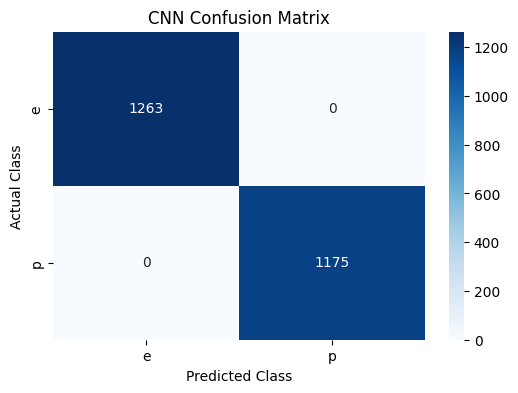

CNN Classification Report:
              precision    recall  f1-score   support

           e       1.00      1.00      1.00      1263
           p       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



In [ ]:
# Confusion Matrix
cnn_cm = confusion_matrix(y_test, cnn_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

# Classification Report
print("CNN Classification Report:")
print(classification_report(
    y_test,
    cnn_predictions,
    target_names=encoder.classes_
))

In [ ]:
from tensorflow.keras.layers import Input

# Build RNN model
rnn_model = Sequential([
    Input(shape=(X_train_dl.shape[1], 1)),
    SimpleRNN(32, activation="tanh"),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

# Compile RNN model
rnn_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,177 (8.50 KB)

 Trainable params: 2,177 (8.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rnn_history = rnn_model.fit(
    X_train_dl,
    y_train,
    batch_size=40,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8747 - loss: 0.3708 - val_accuracy: 0.9139 - val_loss: 0.2334
Epoch 2/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9255 - loss: 0.2037 - val_accuracy: 0.9315 - val_loss: 0.1576
Epoch 3/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9468 - loss: 0.1470 - val_accuracy: 0.9631 - val_loss: 0.0916
Epoch 4/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9587 - loss: 0.1068 - val_accuracy: 0.9622 - val_loss: 0.0961
Epoch 5/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9708 - loss: 0.0895 - val_accuracy: 0.9763 - val_loss: 0.0579
Epoch 6/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9796 - loss: 0.0575 - val_accuracy: 0.9587 - val_loss: 0.1081
Epoch 7/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9850 - loss: 0.0517 - val_accuracy: 0.9938 - val_loss: 0.0221
Epoch 8/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9883 - loss: 0.0365 - val_accu

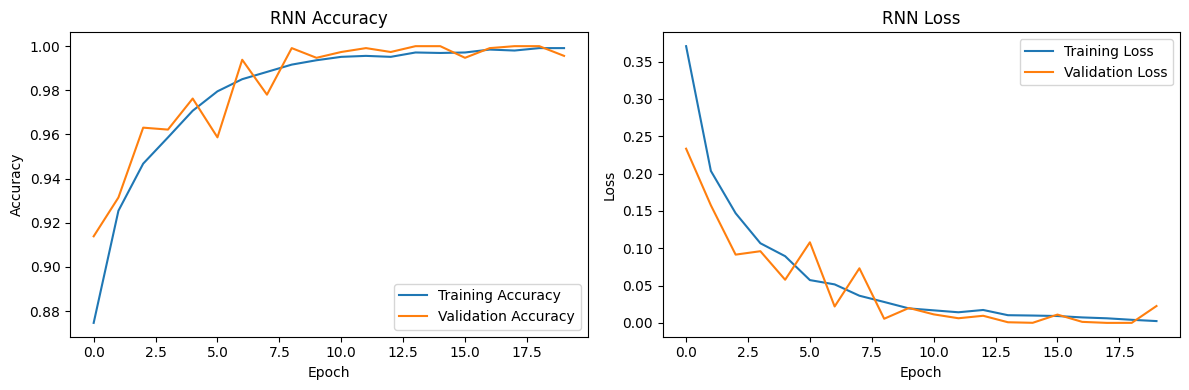

In [ ]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(rnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(rnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(rnn_history.history["loss"], label="Training Loss")
plt.plot(rnn_history.history["val_loss"], label="Validation Loss")
plt.title("RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Generate RNN predictions
rnn_predictions = rnn_model.predict(X_test_dl)

# Convert probabilities into class labels
rnn_predictions = (rnn_predictions > 0.5).astype(int).flatten()

# Calculate test accuracy
rnn_accuracy = accuracy_score(y_test, rnn_predictions)

print("RNN Test Accuracy:", round(rnn_accuracy * 100, 2), "%")

77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
RNN Test Accuracy: 99.47 %


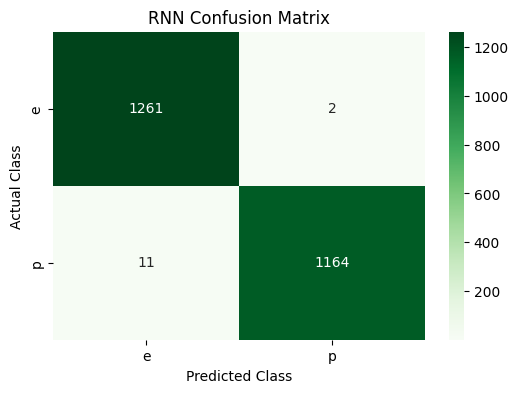

RNN Classification Report:
              precision    recall  f1-score   support

           e       0.99      1.00      0.99      1263
           p       1.00      0.99      0.99      1175

    accuracy                           0.99      2438
   macro avg       0.99      0.99      0.99      2438
weighted avg       0.99      0.99      0.99      2438



In [ ]:
# Generate confusion matrix
rnn_cm = confusion_matrix(y_test, rnn_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(
    rnn_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

# Generate classification report
print("RNN Classification Report:")
print(classification_report(
    y_test,
    rnn_predictions,
    target_names=encoder.classes_
))

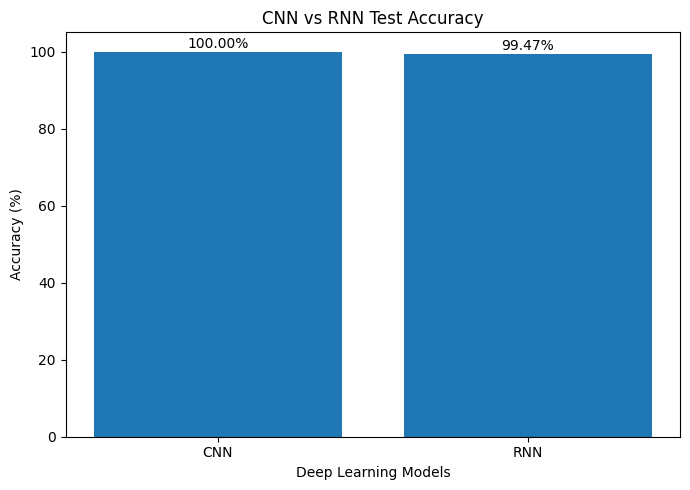

CNN Test Accuracy: 100.00%
RNN Test Accuracy: 99.47%
CNN achieved higher test accuracy.


In [ ]:
# Compare test accuracy
models = ["CNN", "RNN"]
accuracies = [cnn_accuracy * 100, rnn_accuracy * 100]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies)

plt.title("CNN vs RNN Test Accuracy")
plt.xlabel("Deep Learning Models")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

print(f"CNN Test Accuracy: {cnn_accuracy * 100:.2f}%")
print(f"RNN Test Accuracy: {rnn_accuracy * 100:.2f}%")

if cnn_accuracy > rnn_accuracy:
    print("CNN achieved higher test accuracy.")
elif rnn_accuracy > cnn_accuracy:
    print("RNN achieved higher test accuracy.")
else:
    print("Both models achieved equal test accuracy.")

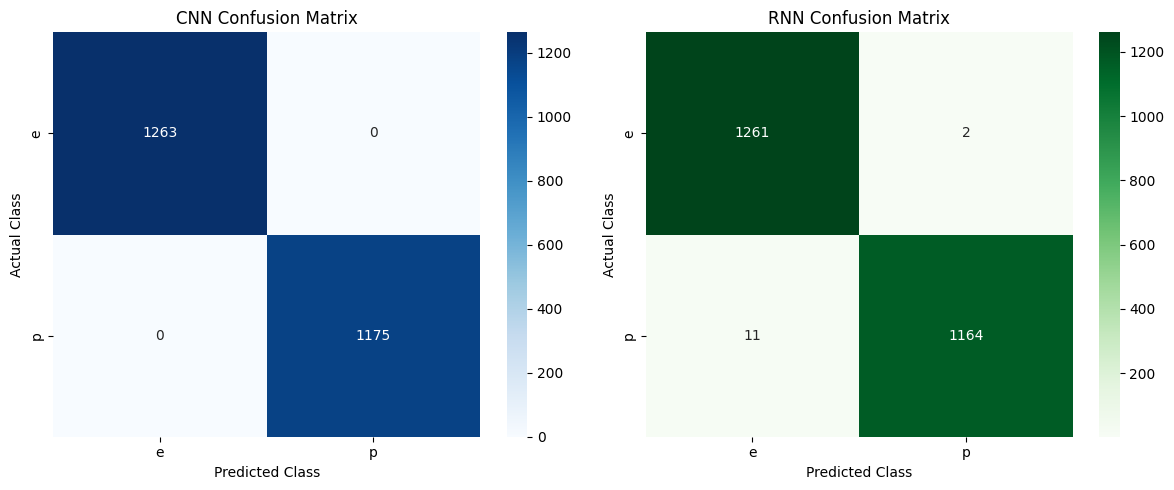

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    ax=axes[0]
)
axes[0].set_title("CNN Confusion Matrix")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("Actual Class")

sns.heatmap(
    rnn_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    ax=axes[1]
)
axes[1].set_title("RNN Confusion Matrix")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [ ]:

# Predict using the RNN model
rnn_predictions = rnn_model.predict(X_test_dl)

# Convert probabilities into 0 or 1
rnn_predictions = (rnn_predictions > 0.5).astype(int).flatten()

# Calculate test accuracy
rnn_accuracy = accuracy_score(y_test, rnn_predictions)

print("RNN Test Accuracy:", round(rnn_accuracy * 100, 2), "%")


77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step
RNN Test Accuracy: 99.47 %


In [ ]:

from sklearn.metrics import classification_report

print("RNN Classification Report:")
print(classification_report(y_test, rnn_predictions, target_names=encoder.classes_))


RNN Classification Report:
              precision    recall  f1-score   support

           e       0.99      1.00      0.99      1263
           p       1.00      0.99      0.99      1175

    accuracy                           0.99      2438
   macro avg       0.99      0.99      0.99      2438
weighted avg       0.99      0.99      0.99      2438



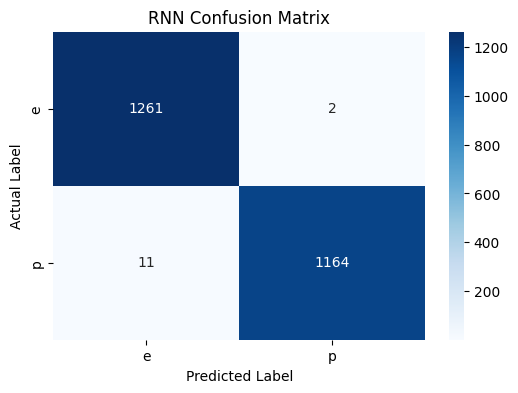

In [ ]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
rnn_cm = confusion_matrix(y_test, rnn_predictions)

# Display confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    rnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


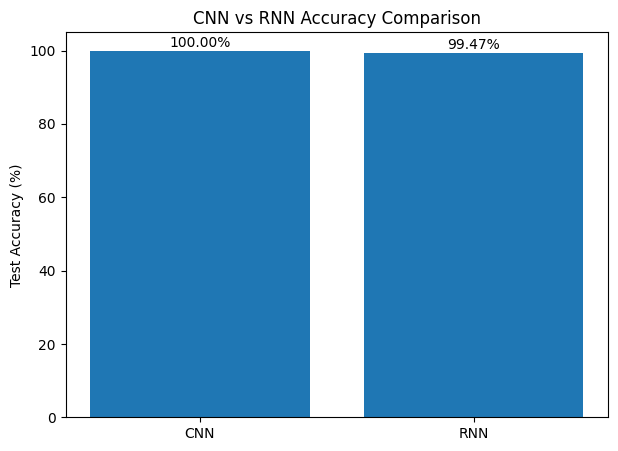

In [ ]:

import matplotlib.pyplot as plt

# Compare model accuracies
models = ["CNN", "RNN"]
accuracies = [cnn_accuracy * 100, rnn_accuracy * 100]

plt.figure(figsize=(7, 5))
plt.bar(models, accuracies)

plt.title("CNN vs RNN Accuracy Comparison")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 105)

for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 1, f"{accuracy:.2f}%", ha="center")

plt.show()
